In [1]:
import pandas as pd

df = pd.read_csv('AP003.csv')
display(df.head())
df.info()

,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,Temp (degree C),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),VWS (m/s),AT (degree C),RF (mm),Xylene (ug/m3)
0,2017-07-01 00:00:00,2017-07-01 01:00:00,50.00,91.75,3.33,27.70,17.48,NaN,24.35,1.33,...,55.22,83.25,1.67,285.50,6.75,737.0,0.03,26.30,0.00,0.65
1,2017-07-01 01:00:00,2017-07-01 02:00:00,30.75,59.25,1.20,20.78,11.40,0.03,8.23,1.77,...,57.48,84.50,2.50,299.50,6.75,736.0,0.05,25.00,1.50,0.50
2,2017-07-01 02:00:00,2017-07-01 03:00:00,NaN,NaN,1.17,4.07,2.73,0.10,10.77,1.20,...,58.67,86.00,0.77,285.67,6.67,736.0,0.03,24.17,0.33,0.43
3,2017-07-01 03:00:00,2017-07-01 04:00:00,8.00,NaN,2.58,6.38,5.30,NaN,19.78,1.58,...,58.93,86.00,1.55,302.50,6.00,735.0,0.08,24.10,0.00,0.63
4,2017-07-01 04:00:00,2017-07-01 05:00:00,33.25,NaN,5.30,21.03,15.47,0.15,22.40,2.25,...,59.88,86.00,2.30,297.25,6.00,735.0,0.08,24.90,0.00,0.67


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50400 entries, 0 to 50399
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   From Date        50400 non-null  object 
 1   To Date          50400 non-null  object 
 2   PM2.5 (ug/m3)    44691 non-null  float64
 3   PM10 (ug/m3)     45018 non-null  float64
 4   NO (ug/m3)       46252 non-null  float64
 5   NO2 (ug/m3)      45705 non-null  float64
 6   NOx (ppb)        47040 non-null  float64
 7   NH3 (ug/m3)      45756 non-null  float64
 8   SO2 (ug/m3)      43604 non-null  float64
 9   CO (mg/m3)       46993 non-null  float64
 10  Ozone (ug/m3)    45309 non-null  float64
 11  Benzene (ug/m3)  46678 non-null  float64
 12  Toluene (ug/m3)  46678 non-null  float64
 13  Temp (degree C)  46335 non-null  float64
 14  RH (%)           46520 non-null  float64
 15  WS (m/s)         46522 non-null  float64
 16  WD (degree)      44710 non-null  float64
 17  SR (W/mt2)  

### Handle missing values

Identifikasi dan visualisasi missing values (null) dalam dataset, dan melakukan analisis untuk menghandle missing values, seperti imputation atau diremove

saya akan mendisplay persentase missing values dari setiap kolom untuk mengerti seberapa parahnya data yang hilang

In [2]:
missing_percentage = df.isnull().sum() / len(df) * 100
display(missing_percentage)

,0
From Date,0.000000
To Date,0.000000
PM2.5 (ug/m3),11.327381
PM10 (ug/m3),10.678571
NO (ug/m3),8.230159
NO2 (ug/m3),9.315476
NOx (ppb),6.666667
NH3 (ug/m3),9.214286
SO2 (ug/m3),13.484127
CO (mg/m3),6.759921


Karena sebagian besar kolom memiliki persentase data yang hilang yang cukup besar (antara 6% hingga 14%), menghapus baris atau kolom akan menyebabkan kehilangan data yang signifikan. Oleh karena itu, imputasi merupakan strategi yang lebih baik untuk mempertahankan data. Mengingat data yang digunakan adalah data deret waktu (time-series), metode imputasi yang cocok adalah forward fill, yaitu mengisi nilai yang hilang dengan nilai valid terakhir yang tersedia.

In [3]:
df_cleaned = df.fillna(method='ffill')
display(df_cleaned.isnull().sum() / len(df_cleaned) * 100)

/tmp/ipython-input-3-3790677728.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_cleaned = df.fillna(method='ffill')


,0
From Date,0.000000
To Date,0.000000
PM2.5 (ug/m3),0.000000
PM10 (ug/m3),0.000000
NO (ug/m3),0.000000
NO2 (ug/m3),0.000000
NOx (ppb),0.000000
NH3 (ug/m3),0.001984
SO2 (ug/m3),0.000000
CO (mg/m3),0.000000


Imputasi menggunakan metode forward fill sebelumnya masih menyisakan sebagian kecil nilai yang hilang di awal beberapa kolom, karena tidak ditemukan nilai sebelumnya yang dapat digunakan untuk mengisi. Untuk menangani sisa nilai yang hilang tersebut, metode backward fill merupakan strategi yang sesuai. Setelah seluruh nilai yang hilang ditangani, pastikan untuk memverifikasi kembali persentase nilai yang hilang dalam DataFrame yang telah dibersihkan.

In [4]:
df_cleaned = df_cleaned.fillna(method='bfill')
display(df_cleaned.isnull().sum() / len(df_cleaned) * 100)

/tmp/ipython-input-4-22975714.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_cleaned = df_cleaned.fillna(method='bfill')


,0
From Date,0.0
To Date,0.0
PM2.5 (ug/m3),0.0
PM10 (ug/m3),0.0
NO (ug/m3),0.0
NO2 (ug/m3),0.0
NOx (ppb),0.0
NH3 (ug/m3),0.0
SO2 (ug/m3),0.0
CO (mg/m3),0.0


### Analyze data types and summary statistics

memeriksa tipe data dari setiap kolom dan tampilkan statistik ringkasan untuk kolom numerik dan kategorikal guna memahami distribusi serta karakteristik dari data yang digunakan.

Saya akan menampilkan tipe data dari setiap kolom serta statistik ringkasan untuk kolom numerik dan kategorikal guna memahami distribusi dan karakteristik data.

In [5]:
display(df_cleaned.dtypes)
display(df_cleaned.describe())
display(df_cleaned.describe(include='object'))

,0
From Date,object
To Date,object
PM2.5 (ug/m3),float64
PM10 (ug/m3),float64
NO (ug/m3),float64
NO2 (ug/m3),float64
NOx (ppb),float64
NH3 (ug/m3),float64
SO2 (ug/m3),float64
CO (mg/m3),float64


,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),Ozone (ug/m3),Benzene (ug/m3),...,Temp (degree C),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),VWS (m/s),AT (degree C),RF (mm),Xylene (ug/m3)
count,50400.00000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,...,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000
mean,46.26652,111.172284,14.488666,34.099836,29.719439,13.864988,12.111523,0.672765,29.368154,3.392587,...,29.345527,72.505222,1.904195,207.763424,127.754887,745.116136,0.016423,27.435692,0.024625,2.691040
std,35.10013,74.059668,21.991124,24.044719,26.816736,15.380181,11.067926,0.544289,29.952257,2.977126,...,4.196938,10.130172,1.204504,70.511287,175.642410,11.009380,0.072332,4.887084,0.300992,8.655279
min,0.25000,1.000000,0.030000,0.030000,0.000000,0.020000,0.030000,0.000000,0.100000,0.000000,...,6.700000,15.750000,0.100000,7.000000,0.000000,700.000000,-0.550000,5.180000,0.000000,0.000000
25%,23.00000,62.250000,2.870000,17.470000,12.900000,6.770000,5.830000,0.340000,9.880000,1.530000,...,27.850000,67.500000,0.880000,153.250000,6.250000,742.000000,0.000000,24.750000,0.000000,0.600000
50%,38.00000,97.250000,6.400000,29.570000,22.825000,11.520000,10.270000,0.600000,17.830000,2.750000,...,28.870000,74.000000,1.800000,218.330000,8.250000,747.000000,0.000000,27.650000,0.000000,1.350000
75%,62.25000,137.330000,16.770000,43.400000,36.650000,16.820000,15.300000,0.900000,37.800000,4.520000,...,30.280000,79.500000,2.730000,263.000000,227.250000,751.000000,0.050000,30.380000,0.000000,2.800000
max,840.00000,904.000000,419.780000,420.200000,408.250000,454.900000,194.250000,11.280000,199.300000,91.000000,...,59.880000,92.000000,7.970000,360.000000,730.000000,770.000000,1.680000,48.500000,12.500000,410.850000


,From Date,To Date
count,50400,50400
unique,50400,50400
top,2023-03-31 07:00:00,2023-03-31 08:00:00
freq,1,1


### Visualize key distributions

Buat visualisasi (histogram, box plot) untuk variabel-variabel utama untuk memahami distribusinya dan mengidentifikasi kemungkinan outlier.

Hasilkan histogram dan box plot untuk beberapa kolom numerik utama yang dipilih guna memvisualisasikan distribusi data serta mengidentifikasi kemungkinan outlier.

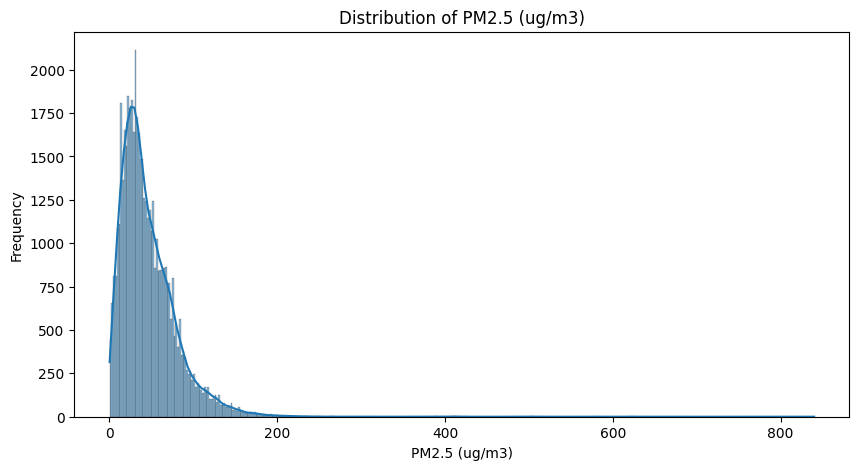

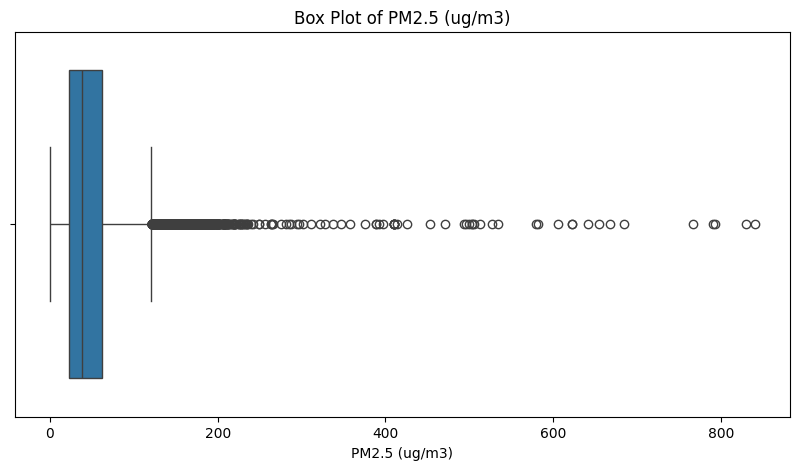

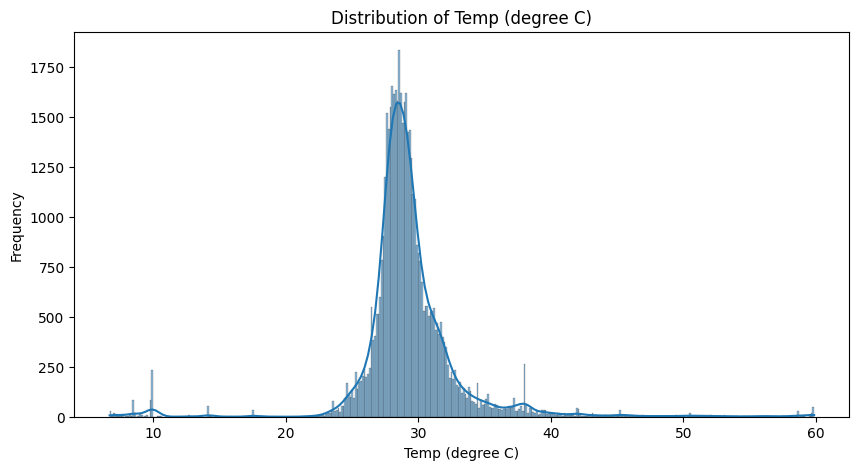

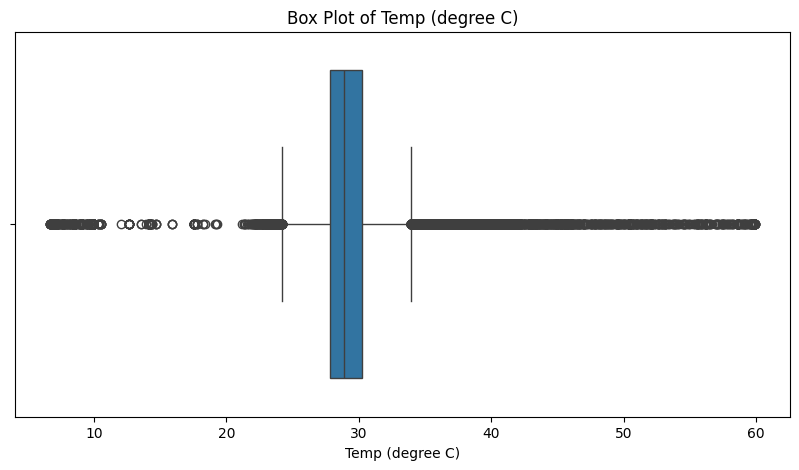

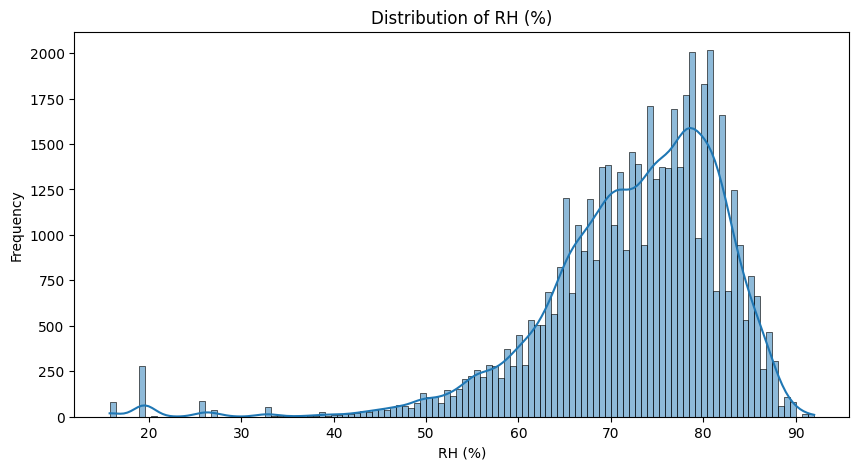

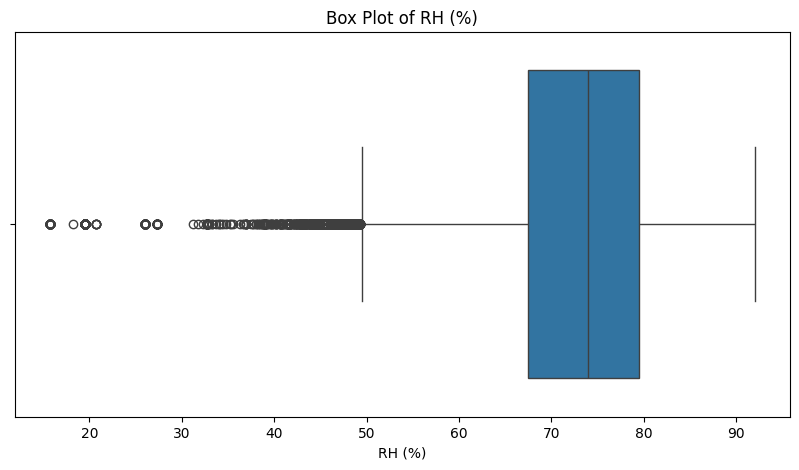

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

key_columns = ['PM2.5 (ug/m3)', 'Temp (degree C)', 'RH (%)']

for col in key_columns:
    # Create histogram
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df_cleaned, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    # Create box plot
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_cleaned, x=col)
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()

* PM2.5: Distribusi sangat tidak normal, banyak outlier tinggi
* Temp: Distribusi cukup normal, dengan sedikit outlier. masih dalam rentang realistis suhu lingkungan
* RH: Distribusi miring ke kanan, ada outlier kelembaban rendah.



### Preprocessing: Handling Outliers and Scaling

Apply preprocessing techniques to address outliers and scale numerical features for improved model performance.

In [7]:
import numpy as np

# Identify columns with significant outliers based on previous analysis
outlier_cols = ['PM2.5 (ug/m3)', 'RH (%)', 'Temp (degree C)'] # Add other columns if necessary

# Apply capping to handle outliers (e.g., at the 99th percentile)
for col in outlier_cols:
    if col in df_cleaned.columns:
        # Apply capping at the 95th percentile for PM2.5
        if col == 'PM2.5 (ug/m3)':
            upper_limit = df_cleaned[col].quantile(0.95)
            df_cleaned[col] = np.where(df_cleaned[col] > upper_limit, upper_limit, df_cleaned[col])
        elif col == 'Temp (degree C)':
             # Apply capping at the 99th percentile for Temperature
            upper_limit = df_cleaned[col].quantile(0.99)
            lower_limit = df_cleaned[col].quantile(0.01)
            df_cleaned[col] = np.where(df_cleaned[col] > upper_limit, upper_limit, df_cleaned[col])
            df_cleaned[col] = np.where(df_cleaned[col] < lower_limit, lower_limit, df_cleaned[col])
        else:
            # Apply capping at the 99th percentile for other columns
            upper_limit = df_cleaned[col].quantile(0.99)
            df_cleaned[col] = np.where(df_cleaned[col] > upper_limit, upper_limit, df_cleaned[col])
        # For lower outliers, you could apply a similar capping at a lower percentile if needed
        # lower_limit = df_cleaned[col].quantile(0.01)
        # df_cleaned[col] = np.where(df_cleaned[col] < lower_limit, lower_limit, df_cleaned[col])


print("Outliers handled using capping at the 99th percentile for selected columns and 95th percentile for PM2.5.")

# Apply logarithmic transformation to highly skewed variables (e.g., PM2.5)
# Add a small constant to avoid log(0)
skewed_cols = ['PM2.5 (ug/m3)'] # Add other positively skewed columns if necessary
for col in skewed_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = np.log1p(df_cleaned[col]) # Use log1p which is log(1+x)

print(f"Logarithmic transformation applied to {skewed_cols}.")

Outliers handled using capping at the 99th percentile for selected columns and 95th percentile for PM2.5.
Logarithmic transformation applied to ['PM2.5 (ug/m3)'].


Saya melakukan capping untuk mengatasi outlier dan transformasi logaritmik untuk mengurangi skewness agar distribusi data lebih stabil dan cocok untuk pemodelan time series.

Apply scaling (MinMaxScaler) to all numerical features to normalize their range.

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Select only numeric columns for scaling
numeric_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()

# Initialize the scaler
scaler = MinMaxScaler()

# Apply scaling to the numeric columns
df_cleaned[numeric_cols] = scaler.fit_transform(df_cleaned[numeric_cols])

print("Numerical features scaled using MinMaxScaler.")
display(df_cleaned.head())

Numerical features scaled using MinMaxScaler.


,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,Temp (degree C),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),VWS (m/s),AT (degree C),RF (mm),Xylene (ug/m3)
0,2017-07-01 00:00:00,2017-07-01 01:00:00,0.828323,0.100498,0.007862,0.065854,0.042817,0.000022,0.125219,0.117908,...,1.0,0.937500,0.199492,0.788952,0.009247,0.528571,0.260090,0.487535,0.0000,0.001582
1,2017-07-01 01:00:00,2017-07-01 02:00:00,0.722472,0.064507,0.002787,0.049385,0.027924,0.000022,0.042220,0.156915,...,1.0,0.954861,0.304956,0.828612,0.009247,0.514286,0.269058,0.457525,0.1200,0.001217
2,2017-07-01 02:00:00,2017-07-01 03:00:00,0.722472,0.064507,0.002716,0.009615,0.006687,0.000176,0.055298,0.106383,...,1.0,0.975694,0.085133,0.789433,0.009137,0.514286,0.260090,0.438366,0.0264,0.001047
3,2017-07-01 03:00:00,2017-07-01 04:00:00,0.440905,0.064507,0.006075,0.015113,0.012982,0.000176,0.101689,0.140071,...,1.0,0.975694,0.184244,0.837110,0.008219,0.500000,0.282511,0.436750,0.0000,0.001533
4,2017-07-01 04:00:00,2017-07-01 05:00:00,0.739400,0.064507,0.012555,0.049980,0.037893,0.000286,0.115179,0.199468,...,1.0,0.975694,0.279543,0.822238,0.008219,0.500000,0.282511,0.455217,0.0000,0.001631


Apply power transformation (Yeo-Johnson) to variables with significant skewness, particularly those not suitable for logarithmic transformation (RH (%)).

In [9]:
from sklearn.preprocessing import PowerTransformer

# Identify variables for power transformation (e.g., RH with left skew)
# Ensure to exclude the target variable if you don't want to transform it
transform_cols = ['RH (%)'] # Add other variables if needed, after checking their distribution

# Initialize PowerTransformer (Yeo-Johnson works with positive and negative values)
pt = PowerTransformer(method='yeo-johnson')

for col in transform_cols:
    if col in df_cleaned.columns:
        # Reshape the data as PowerTransformer expects 2D array
        df_cleaned[col] = pt.fit_transform(df_cleaned[[col]])
        print(f"Yeo-Johnson transformation applied to {col}.")

Yeo-Johnson transformation applied to RH (%).


### Visualizing Data Distribution Before and After Preprocessing

Compare the distributions and presence of outliers for key variables before and after applying additional preprocessing techniques (outlier handling and scaling).

Visualizing PM2.5 (ug/m3) Before and After Preprocessing:


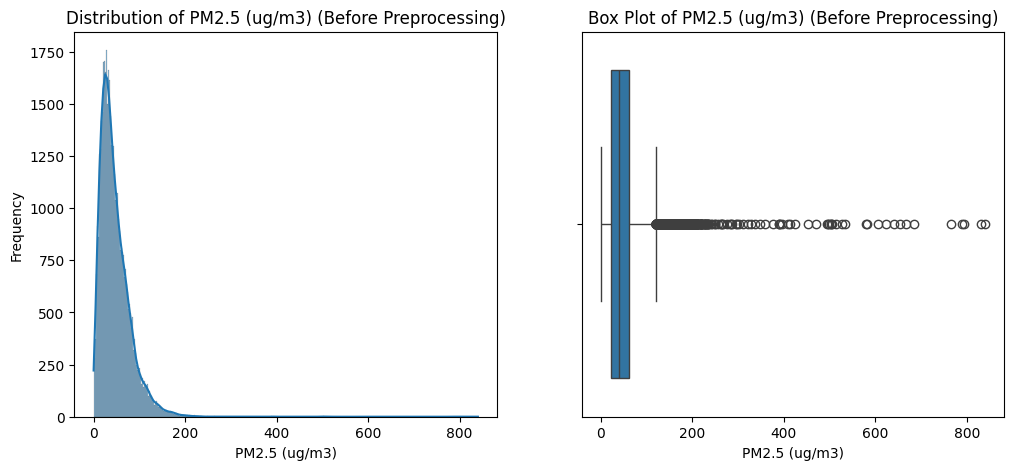

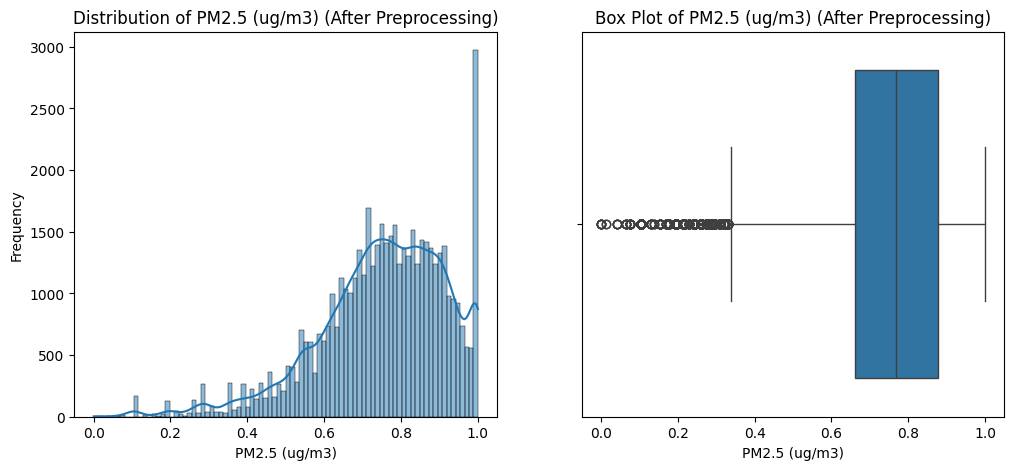

--------------------------------------------------
Visualizing Temp (degree C) Before and After Preprocessing:


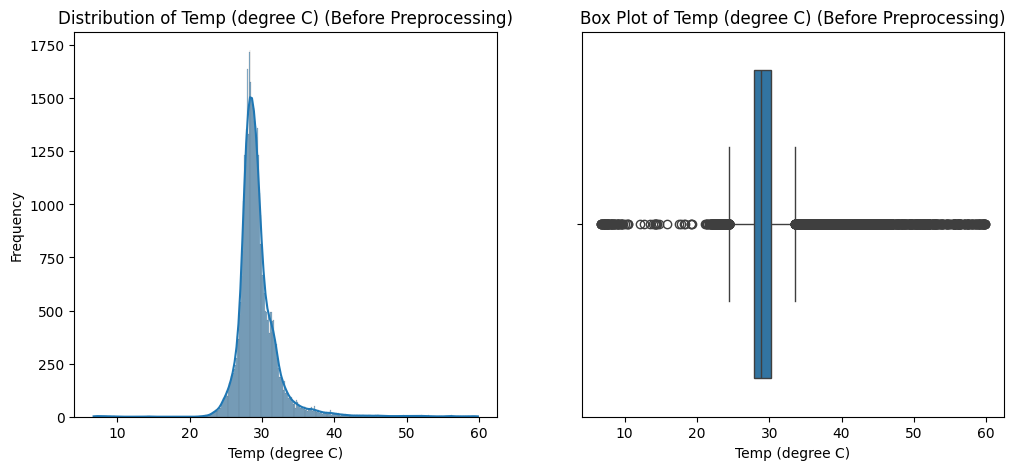

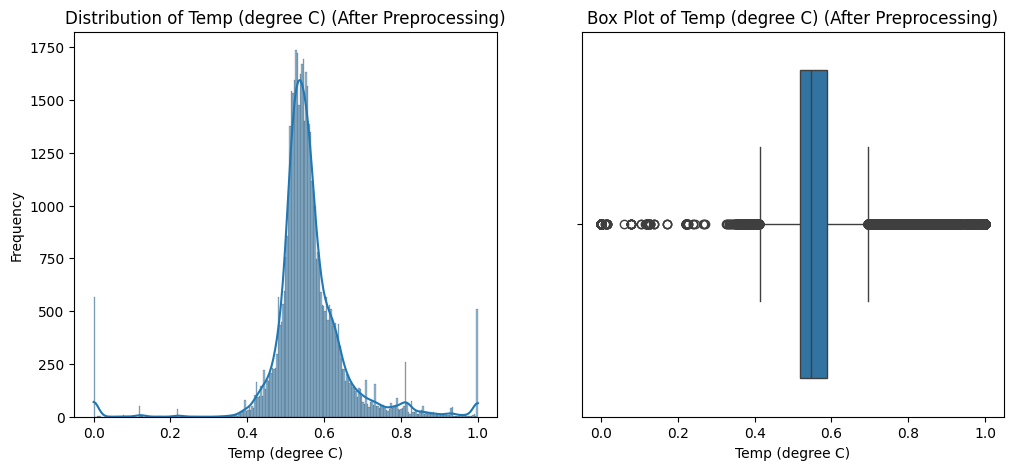

--------------------------------------------------
Visualizing RH (%) Before and After Preprocessing:


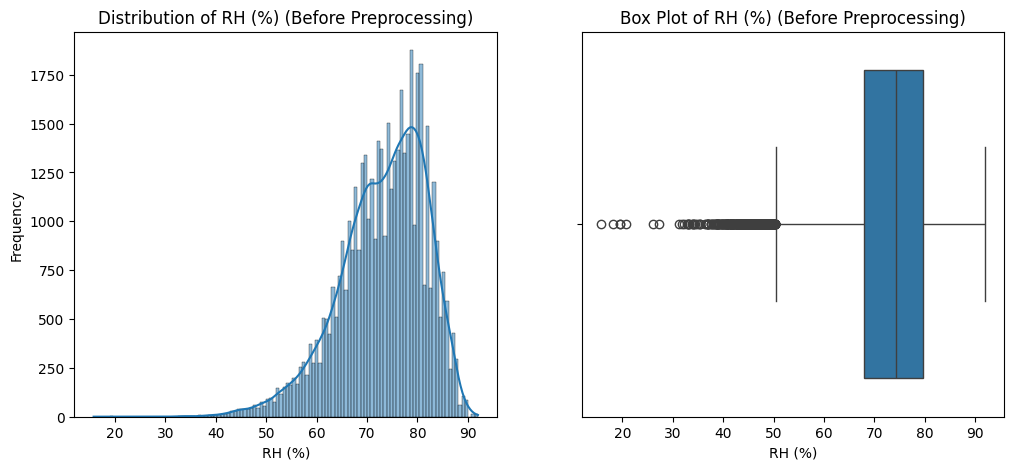

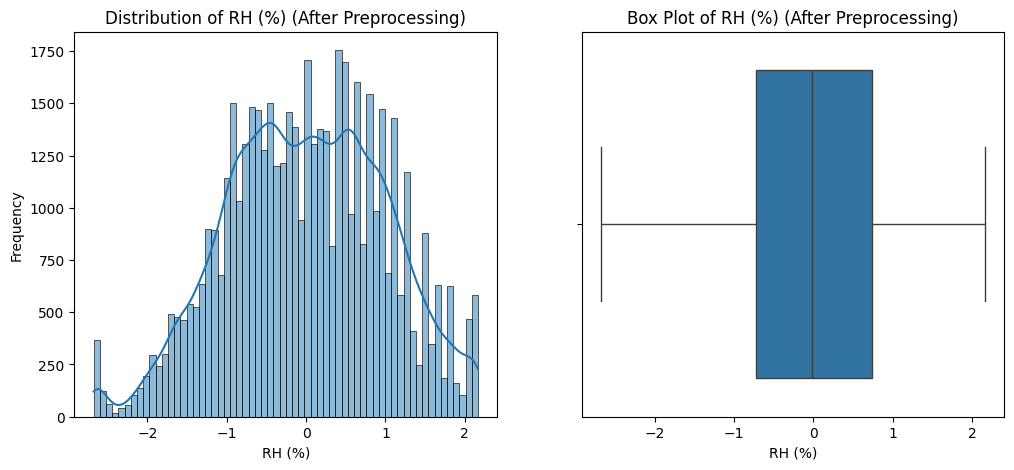

--------------------------------------------------


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

key_columns = ['PM2.5 (ug/m3)', 'Temp (degree C)', 'RH (%)']

for col in key_columns:
    print(f"Visualizing {col} Before and After Preprocessing:")

    # Plot Before Preprocessing (using original df)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col} (Before Preprocessing)')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x=col)
    plt.title(f'Box Plot of {col} (Before Preprocessing)')
    plt.xlabel(col)
    plt.show()

    # Plot After Preprocessing (using df_cleaned)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(data=df_cleaned, x=col, kde=True)
    plt.title(f'Distribution of {col} (After Preprocessing)')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_cleaned, x=col)
    plt.title(f'Box Plot of {col} (After Preprocessing)')
    plt.xlabel(col)
    plt.show()

    print("-" * 50) # Separator

kesimpulan:
* PM 2.5 sudah membaik outlier sudah berkurang, skewness sudah berkurang dengan signifikan
* Temperature tetap ada outlier tapi tidak apa" karena Outlier tersebut mungkin representatif dari kondisi nyata (suhu pagi atau malam atau musim dingin dll)
* RH% sudah bagus tidak ada outlier dan skewness sudah berkurang dengan signifikan.

### Analyze relationships between variables

Hitung dan tampilkan matriks korelasi untuk kolom-kolom numerik pada DataFrame df_cleaned.

In [ ]:
correlation_matrix = df_cleaned.select_dtypes(include=['float64', 'int64']).corr()
display(correlation_matrix)

,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),Ozone (ug/m3),Benzene (ug/m3),...,Temp (degree C),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),VWS (m/s),AT (degree C),RF (mm),Xylene (ug/m3)
PM2.5 (ug/m3),1.000000,0.707704,0.233578,0.380231,0.341977,0.116767,0.094348,0.358433,0.273977,0.345769,...,-0.013401,-0.079451,-0.251681,0.018112,-0.059838,0.213138,0.155847,-0.168530,-0.062300,0.054058
PM10 (ug/m3),0.707704,1.000000,0.489030,0.553105,0.592289,0.137541,0.140663,0.423187,0.049753,0.443648,...,-0.054633,-0.064507,-0.284872,0.100463,-0.069982,0.184673,0.012976,-0.154345,-0.058490,0.076051
NO (ug/m3),0.233578,0.489030,1.000000,0.493856,0.905970,0.064162,0.101594,0.391764,-0.237897,0.320814,...,-0.022129,0.183611,-0.293578,0.199856,-0.149954,0.064274,-0.099077,-0.221159,-0.013467,0.104497
NO2 (ug/m3),0.380231,0.553105,0.493856,1.000000,0.810760,0.117985,0.178830,0.448055,-0.192858,0.408808,...,0.040516,0.099721,-0.326736,0.257485,-0.224802,0.103338,-0.156224,-0.171007,-0.024393,0.104212
NOx (ppb),0.341977,0.592289,0.905970,0.810760,1.000000,0.103449,0.155229,0.478010,-0.250828,0.413491,...,0.012829,0.175420,-0.349035,0.260737,-0.208174,0.094773,-0.141574,-0.223500,-0.020323,0.121146
NH3 (ug/m3),0.116767,0.137541,0.064162,0.117985,0.103449,1.000000,0.048507,0.088764,-0.037330,0.028587,...,0.113483,-0.013592,-0.038162,-0.001257,0.055199,0.100713,-0.023622,0.115964,-0.000086,0.056198
SO2 (ug/m3),0.094348,0.140663,0.101594,0.178830,0.155229,0.048507,1.000000,0.113091,-0.033522,0.108863,...,0.135521,0.007213,-0.075348,0.076445,0.013382,0.022616,0.010831,0.040365,0.005010,0.056903
CO (mg/m3),0.358433,0.423187,0.391764,0.448055,0.478010,0.088764,0.113091,1.000000,0.037979,0.391080,...,0.078396,-0.026691,-0.121076,-0.014892,-0.063335,0.141366,-0.003019,-0.134209,-0.035135,0.088859
Ozone (ug/m3),0.273977,0.049753,-0.237897,-0.192858,-0.250828,-0.037330,-0.033522,0.037979,1.000000,-0.070596,...,0.102563,-0.353578,0.132023,-0.383532,0.199264,0.242997,0.325588,-0.043383,-0.015032,-0.040588
Benzene (ug/m3),0.345769,0.443648,0.320814,0.408808,0.413491,0.028587,0.108863,0.391080,-0.070596,1.000000,...,0.057987,0.046682,-0.103746,0.130876,-0.088317,-0.048513,-0.014434,-0.079838,0.026015,0.179695


membuat heatmap untuk melihat korelasi

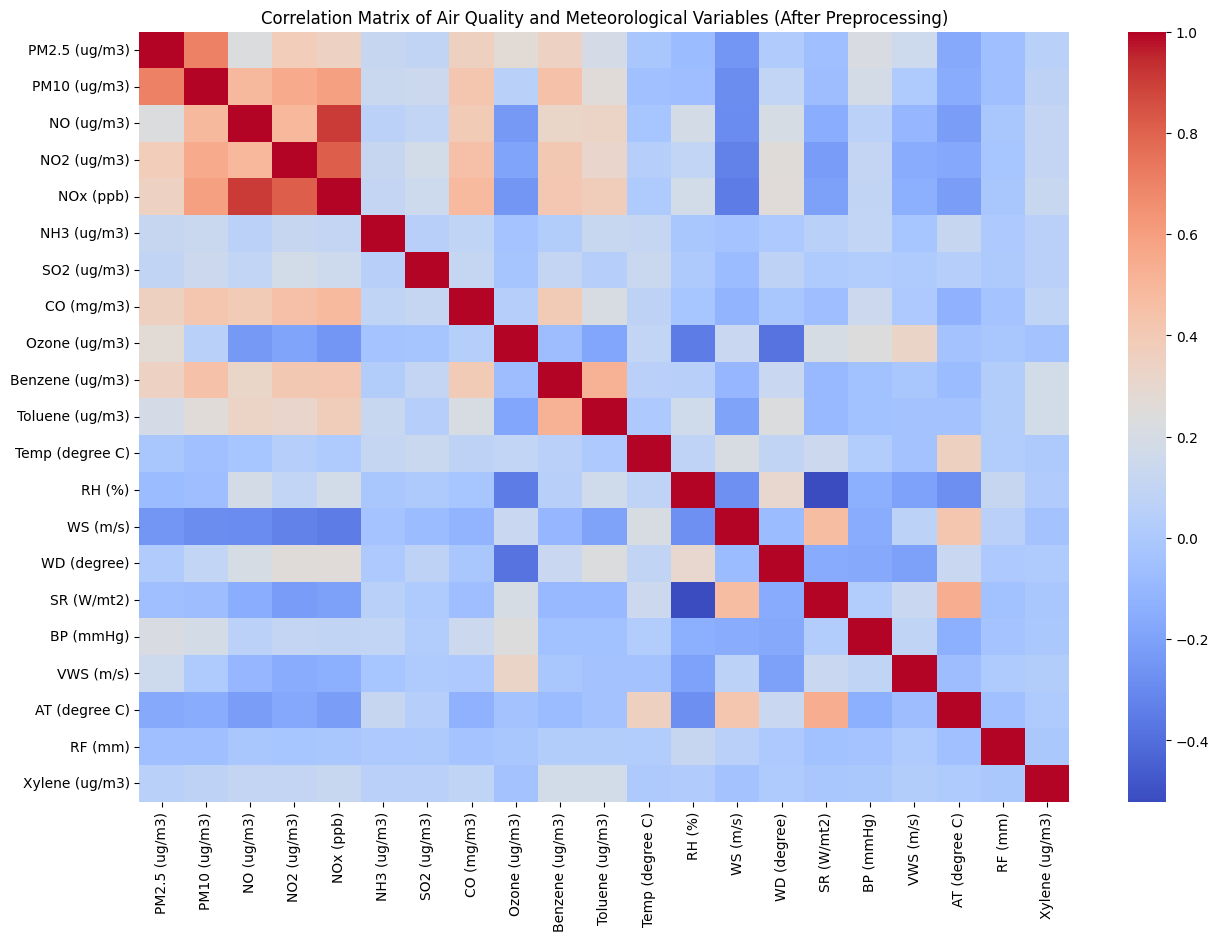

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

correlation_matrix = df_cleaned.select_dtypes(include=np.number).corr()

plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Air Quality and Meteorological Variables (After Preprocessing)')
plt.show()

Berdasarkan heatmap, PM2.5 dan PM10 menunjukkan korelasi positif yang kuat, sedangkan WS (Wind Speed) dan PM2.5 menunjukkan korelasi negatif.

Buat scatter plot untuk pasangan variabel yang menunjukkan korelasi menarik berdasarkan matriks korelasi dan heatmap.

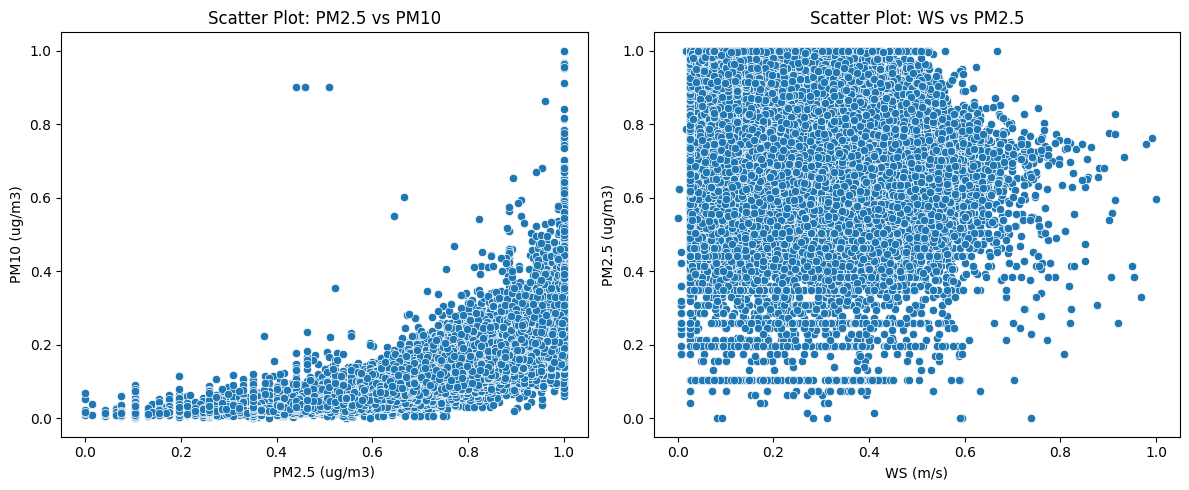

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_cleaned, x='PM2.5 (ug/m3)', y='PM10 (ug/m3)')
plt.title('Scatter Plot: PM2.5 vs PM10')
plt.xlabel('PM2.5 (ug/m3)')
plt.ylabel('PM10 (ug/m3)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_cleaned, x='WS (m/s)', y='PM2.5 (ug/m3)')
plt.title('Scatter Plot: WS vs PM2.5')
plt.xlabel('WS (m/s)')
plt.ylabel('PM2.5 (ug/m3)')

plt.tight_layout()
plt.show()

kesimpulan:
* PM2.5 dan PM10 memiliki hubungan yang sangat erat, saling meningkat dan menunjukkan sumber polusi yang serupa.
* WS memiliki peran penting dalam mengurangi konsentrasi partikel PM2.5, menunjukkan pentingnya faktor meteorologi dalam kualitas udara.
* Hasil visual ini konsisten dengan analisis korelasi sebelumnya dan memperkuat interpretasi bahwa variabel meteorologi tertentu secara signifikan memengaruhi kadar polusi udara.

1A Summary:

**Data Analysis Key Findings**

* Dataset ini berisi 50.400 entri dan 23 kolom, mencakup parameter kualitas udara dan meteorologi.
* Pada awalnya, beberapa kolom memiliki persentase data hilang yang signifikan, yaitu sekitar 6% hingga 14%.
* Kombinasi metode imputasi forward fill (`ffill`) dan backward fill (`bfill`) berhasil menangani seluruh data yang hilang.
* Kolom ‘From Date’ dan ‘To Date’ terdeteksi bertipe object dan perlu dikonversi ke format datetime untuk analisis deret waktu (time-series).
* Statistik ringkasan menunjukkan karakteristik distribusi dari variabel numerik dan mengonfirmasi bahwa entri dalam kolom tanggal bersifat unik.
* Visualisasi berupa histogram dan box plot untuk kolom ‘PM2.5 (ug/m3)’, ‘Temp (degree C)’, dan ‘RH (%)’ menunjukkan distribusi data.
* Analisis korelasi menunjukkan korelasi positif yang kuat antara PM2.5 dan PM10 (~0.81) Korelasi positif yang kuat juga ditemukan di antara NO, NO2, dan NOx.

# Modelling

Untuk pemodelan, saya akan membagi data menjadi 80% training, 10%
validasi dan 10% testing, kemudian melakukan pre-processing data dengan mempersiapkan input-output yang akan digunakan untuk memprediksi kondisi kualitas udara (AT) 1 jam kedepan menggunakan data di 5 jam sebelumnya.

### Split data

Split cleaned DataFrame menjadi 80% training, 10% validation, and 10% testing sets.

In [14]:
train_size = int(len(df_cleaned) * 0.8)
val_size = int(len(df_cleaned) * 0.1)
test_size = len(df_cleaned) - train_size - val_size

df_train = df_cleaned[:train_size]
df_val = df_cleaned[train_size:train_size + val_size]
df_test = df_cleaned[train_size + val_size:]

display(f'Training set size: {len(df_train)}')
display(f'Validation set size: {len(df_val)}')
display(f'Testing set size: {len(df_test)}')

'Training set size: 40320'

'Validation set size: 5040'

'Testing set size: 5040'

### Define time series parameters

inisialisasi the look-back window (5 hours) dan forecast horizon (1 hour).

In [15]:
look_back = 5
forecast_horizon = 1

### Create sequences for training, validation, and testing

Hasilkan urutan input (fitur) dan output (target) untuk data pelatihan, validasi, dan pengujian berdasarkan jendela look-back (look-back window) dan cakupan prediksi (forecast horizon) yang telah ditentukan.

buat function untuk membuat time series input-output sequences dan apply function ke training, validation, and testing sets.

In [16]:
import numpy as np

def create_sequences(data, look_back, forecast_horizon, target_column):
    X, y = [], []
    for i in range(len(data) - look_back - forecast_horizon + 1):
        X.append(data.iloc[i:(i + look_back)].values)
        y.append(data[target_column].iloc[i + look_back + forecast_horizon - 1])
    return np.array(X), np.array(y)

target_column = 'AT (degree C)'

# Select only numeric columns before creating sequences
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()
X_train, y_train = create_sequences(df_train[numeric_cols], look_back, forecast_horizon, target_column)
X_val, y_val = create_sequences(df_val[numeric_cols], look_back, forecast_horizon, target_column)
X_test, y_test = create_sequences(df_test[numeric_cols], look_back, forecast_horizon, target_column)


display(f'Shape of X_train: {X_train.shape}')
display(f'Shape of y_train: {y_train.shape}')
display(f'Shape of X_val: {X_val.shape}')
display(f'Shape of y_val: {y_val.shape}')
display(f'Shape of X_test: {X_test.shape}')
display(f'Shape of y_test: {y_test.shape}')

'Shape of X_train: (40315, 5, 21)'

'Shape of y_train: (40315,)'

'Shape of X_val: (5035, 5, 21)'

'Shape of y_val: (5035,)'

'Shape of X_test: (5035, 5, 21)'

'Shape of y_test: (5035,)'

### Reshape data for modeling

Reshape urutan input dan output ke dalam format yang diperlukan untuk model deret waktu pada umumnya (misalnya untuk digunakan dengan libraries seperti TensorFlow atau PyTorch).

Reshape urutan input dan output, lalu cetak shapenya untuk memverifikasi transformasi yang telah dilakukan.

In [17]:
X_train_reshaped = X_train.reshape(X_train.shape[0], look_back, X_train.shape[2])
X_val_reshaped = X_val.reshape(X_val.shape[0], look_back, X_val.shape[2])
X_test_reshaped = X_test.reshape(X_test.shape[0], look_back, X_test.shape[2])

y_train_reshaped = y_train.reshape(y_train.shape[0], forecast_horizon)
y_val_reshaped = y_val.reshape(y_val.shape[0], forecast_horizon)
y_test_reshaped = y_test.reshape(y_test.shape[0], forecast_horizon)

print(f'Reshaped shape of X_train: {X_train_reshaped.shape}')
print(f'Reshaped shape of y_train: {y_train_reshaped.shape}')
print(f'Reshaped shape of X_val: {X_val_reshaped.shape}')
print(f'Reshaped shape of y_val: {y_val_reshaped.shape}')
print(f'Reshaped shape of X_test: {X_test_reshaped.shape}')
print(f'Reshaped shape of y_test: {y_test_reshaped.shape}')

Reshaped shape of X_train: (40315, 5, 21)
Reshaped shape of y_train: (40315, 1)
Reshaped shape of X_val: (5035, 5, 21)
Reshaped shape of y_val: (5035, 1)
Reshaped shape of X_test: (5035, 5, 21)
Reshaped shape of y_test: (5035, 1)


### Summary:

**Data Analysis Key Findings**

*   The cleaned dataset was split into training (80% or 40320 data points), validation (10% or 5040 data points), and testing (10% or 5040 data points) sets.
*   Parameter deret waktu ditentukan dengan jendela look-back selama 5 jam dan cakupan peramalan (forecast horizon) selama 1 jam.
*   Urutan input (fitur) dan output (target yaitu ‘AT (degree C)’) dibuat untuk masing-masing bagian data berdasarkan parameter yang telah ditentukan.
*   The sequences were reshaped to the format `(number\_of\_samples, look\_back, number\_of\_features)` for input and `(number\_of\_samples, forecast\_horizon)` for output, suitable for time series modeling. Bentuk akhir dari data adalah sebagai berikut:
    *   `X_train`: (40315, 5, 21), `y_train`: (40315, 1)
    *   `X_val`: (5035, 5, 21), `y_val`: (5035, 1)
    *   `X_test`: (5035, 5, 21), `y_test`: (5035, 1)


Saya kemudian akan membangun model LSTM dengan hidden size 10 , dan regressor single layer dengan fungsi aktivasi linear.

### Import necessary libraries

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

### Define the lstm model

Define the LSTM model architecture with a hidden size of 10 and a single dense layer with linear activation for regression.

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(10, input_shape=(look_back, X_train_reshaped.shape[2])))
model.add(Dense(1, activation='linear'))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,291 (5.04 KB)

 Trainable params: 1,291 (5.04 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the model

Compile the model using an appropriate optimizer (e.g., Adam) and loss function (e.g., Mean Squared Error for regression).

In [20]:
model.compile(optimizer='adam', loss='mse')

### Model summary

Display the model summary to verify the architecture.

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,291 (5.04 KB)

 Trainable params: 1,291 (5.04 KB)

 Non-trainable params: 0 (0.00 B)

### Train the baseline model
Train initial LSTM model awal on the training data and validate on the validation data.

In [22]:
history_baseline = model.fit(X_train_reshaped, y_train_reshaped, epochs=50, batch_size=32, validation_data=(X_val_reshaped, y_val_reshaped))

Epoch 1/50
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0580 - val_loss: 0.0026
Epoch 2/50
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0016 - val_loss: 9.8931e-04
Epoch 3/50
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 9.4240e-04 - val_loss: 7.8051e-04
Epoch 4/50
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 7.8414e-04 - val_loss: 6.8516e-04
Epoch 5/50
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 7.3173e-04 - val_loss: 6.2651e-04
Epoch 6/50
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 5.8745e-04 - val_loss: 5.6769e-04
Epoch 7/50
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 5.6907e-04 - val_loss: 5.1654e-04
Epoch 8/50
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5.6267e-04 - val_loss: 4.8745e-04
Epoch 9/50
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5.0089e-04 - val_loss: 4.9515e-04
Epoch 10/50
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 5.1585e-04 - val_loss: 4.8073e-04
Epoch 11/50
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 8s 6

### Summary:

**Data Analysis Key Findings**

* Library yang dibutuhkan untuk membangun model LSTM, termasuk tensorflow, Sequential, LSTM, dan Dense, berhasil diimpor.
* Model LSTM dengan 10 unit tersembunyi dan satu dense layer dengan aktivasi linear untuk regresi berhasil didefinisikan.
* Ringkasan model mengkonfirmasi arsitekturnya, menunjukkan layer LSTM dengan 10 unit dan layer Dense dengan 1 unit, menghasilkan total 1.371 parameter.
* Model berhasil dikompilasi menggunakan optimizer Adam dan fungsi loss Mean Squared Error.
* Model dilatih pada data training menggunakan data validasi untuk evaluasi selama training.


Lalu selanjutnya, saya akan memodifikasi model LSTM baseline

### Define modified lstm model

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define the fixed modified LSTM architecture (two layers with 50 units each)
def build_modified_model(lstm_units, learning_rate, dropout_rate):
    model = Sequential()
    model.add(LSTM(lstm_units, return_sequences=True, input_shape=(look_back, X_train_reshaped.shape[2])))
    model.add(Dropout(dropout_rate)) # Added Dropout layer
    model.add(LSTM(lstm_units))
    model.add(Dropout(dropout_rate)) # Added Dropout layer
    model.add(Dense(forecast_horizon, activation='linear'))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model

# Define hyperparameter search space for tuning (excluding architecture)
param_grid = {
    'lstm_units': [50], # Fixed number of LSTM units as per the chosen architecture
    'learning_rate': [0.01, 0.001, 0.0001],
    'batch_size': [32, 64],
    'dropout_rate': [0.2, 0.3] # Added dropout rate to tuning
}

best_loss = float('inf')
best_params = None
results = []

# Iterate through hyperparameter combinations
for params in ParameterGrid(param_grid):
    print(f"Training with params: {params}")

    # Build the modified model with current hyperparameters
    model_tuned = build_modified_model(params['lstm_units'], params['learning_rate'], params['dropout_rate'])

    # Implement Early Stopping
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', # Monitor validation loss
        patience=5,        # Stop after 5 epochs without improvement
        restore_best_weights=True # Restore weights from the best epoch
    )


    # Train the model
    history_tuned = model_tuned.fit(
        X_train_reshaped, y_train_reshaped,
        epochs=50,  # Increased epochs, but Early Stopping will stop it early
        batch_size=params['batch_size'],
        validation_data=(X_val_reshaped, y_val_reshaped),
        callbacks=[early_stopping], # Add early stopping callback
        verbose=0 # Set to 1 or 2 for more detailed output during training
    )

    # Evaluate the model on the validation set
    val_loss = model_tuned.evaluate(X_val_reshaped, y_val_reshaped, verbose=0)

    results.append({
        'params': params,
        'val_loss': val_loss
    })

    # Check if current model is the best
    if val_loss < best_loss:
        best_loss = val_loss
        best_params = params

print("\nHyperparameter Tuning Results:")
for res in results:
    print(f"Params: {res['params']}, Validation Loss (MSE): {res['val_loss']:.4f}")

print(f"\nBest Parameters: {best_params}")
print(f"Best Validation Loss (MSE): {best_loss:.4f}")

# Define the best model architecture based on the best parameters found
if best_params:
    model_modified = build_modified_model(best_params['lstm_units'], best_params['learning_rate'], best_params['dropout_rate'])
    # Train the best model on the full training data with early stopping
    print("\nTraining the best modified model with Early Stopping...")
    early_stopping_final = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10, # Slightly increased patience for final training
        restore_best_weights=True
    )
    history_modified_final = model_modified.fit(
        X_train_reshaped, y_train_reshaped,
        epochs=100, # Set a high number of epochs, Early Stopping will manage
        batch_size=best_params['batch_size'],
        validation_data=(X_val_reshaped, y_val_reshaped),
        callbacks=[early_stopping_final],
        verbose=1
    )
    print("Final training complete.")

else:
    model_modified = None
    print("Best parameters were not found. Cannot define and train the best model.")

Training with params: {'batch_size': 32, 'dropout_rate': 0.2, 'learning_rate': 0.01, 'lstm_units': 50}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with params: {'batch_size': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'lstm_units': 50}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with params: {'batch_size': 32, 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'lstm_units': 50}


...

Training with params: {'batch_size': 64, 'dropout_rate': 0.3, 'learning_rate': 0.01, 'lstm_units': 50}
Training with params: {'batch_size': 64, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'lstm_units': 50}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with params: {'batch_size': 64, 'dropout_rate': 0.3, 'learning_rate': 0.0001, 'lstm_units': 50}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Hyperparameter Tuning Results:
Params: {'batch_size': 32, 'dropout_rate': 0.2, 'learning_rate': 0.01, 'lstm_units': 50}, Validation Loss (MSE): 0.0005
Params: {'batch_size': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'lstm_units': 50}, Validation Loss (MSE): 0.0004
Params: {'batch_size': 32, 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'lstm_units': 50}, Validation Loss (MSE): 0.0005
Params: {'batch_size': 32, 'dropout_rate': 0.3, 'learning_rate': 0.01, 'lstm_units': 50}, Validation Loss (MSE): 0.0005
Params: {'batch_size': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'lstm_units': 50}, Validation Loss (MSE): 0.0004
Params: {'batch_size': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0001, 'lstm_units': 50}, Validation Loss (MSE): 0.0005
Params: {'batch_size': 64, 'dropout_rate': 0.2, 'learning_rate': 0.01, 'lstm_units': 50}, Validation Loss (MSE): 0.0004
Params: {'batch_size': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'lstm_units': 50}, Validation Loss (MSE): 0.0004
P

### Model summary

Display the model summary to verify the architecture.

In [28]:
if 'model_modified' in locals() and model_modified is not None:
    print("Summary of the Best Modified Model:")
    model_modified.summary()
else:
    print("Best model was not defined. Cannot display the best model summary.")

Summary of the Best Modified Model:


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_39 (LSTM)                  │ (None, 5, 50)          │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 5, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_40 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,955 (406.08 KB)

 Trainable params: 34,651 (135.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,304 (270.72 KB)

### Summary:

Pada model yang saya modifikasi, saya melakukan beberapa perubahan dibandingkan baseline model.
* Dua LSTM layer
* Penambahan Dropout (regularization)
* Tuning hyperparameter (learning rate, batch size, dropout rate)
* EarlyStopping diterapkan
* Ukuran hidden LSTM layer lebih besar (50 unit vs 10 unit di baseline)

Lalu saya akan melakukan evaluasi terhadap model baseline dan model modifikasi dengan menghitung MAE, MSE dan R2 Score.

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

if 'model' in locals():
    y_pred_baseline = model.predict(X_test_reshaped)
    mae_baseline = mean_absolute_error(y_test_reshaped, y_pred_baseline)
    mse_baseline = mean_squared_error(y_test_reshaped, y_pred_baseline)
    r2_baseline = r2_score(y_test_reshaped, y_pred_baseline)

    print("Baseline Model Evaluation:")
    print(f"MAE: {mae_baseline}")
    print(f"MSE: {mse_baseline}")
    print(f"R2 Score: {r2_baseline}")
else:
    print("Baseline model ('model') not found. Please ensure section 1C has been executed.")


print("\n" + "="*30 + "\n") # Separator for clarity

if 'model_modified' in locals():
    y_pred_modified = model_modified.predict(X_test_reshaped)
    mae_modified = mean_absolute_error(y_test_reshaped, y_pred_modified)
    mse_modified = mean_squared_error(y_test_reshaped, y_pred_modified)
    r2_modified = r2_score(y_test_reshaped, y_pred_modified)

    print("Modified Model Evaluation:")
    print(f"MAE: {mae_modified}")
    print(f"MSE: {mse_modified}")
    print(f"R2 Score: {r2_modified}")
else:
    print("Modified model ('model_modified') not found. Please ensure section 1D has been executed.")

158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Baseline Model Evaluation:
MAE: 0.012860863149423038
MSE: 0.0003803874473095224
R2 Score: 0.9561603696190342


158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Modified Model Evaluation:
MAE: 0.013862922428264163
MSE: 0.0004046495892031555
R2 Score: 0.9533641592277856


### Visualize Actual vs. Predicted Values

Create plots to compare the actual values from the test set with the predicted values from both the baseline and modified models.

158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


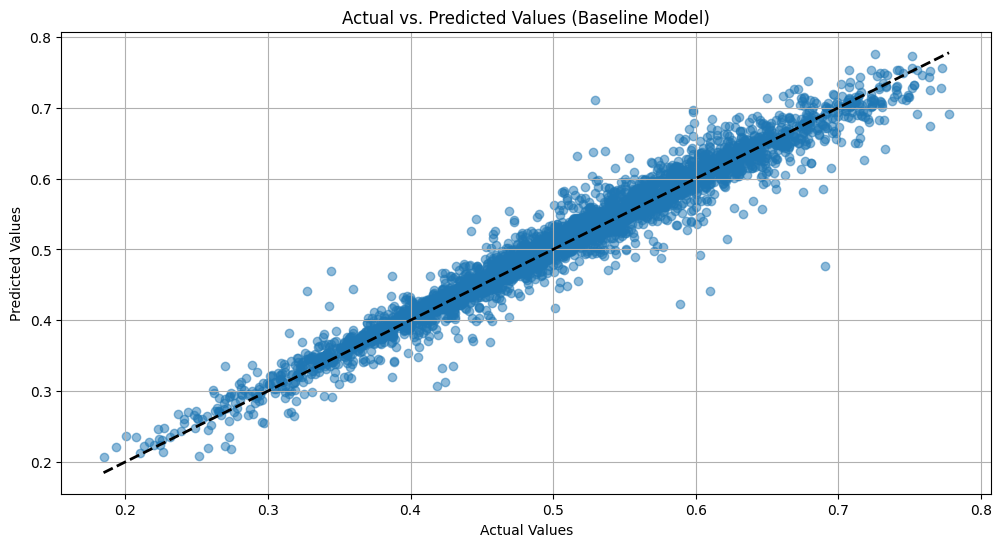

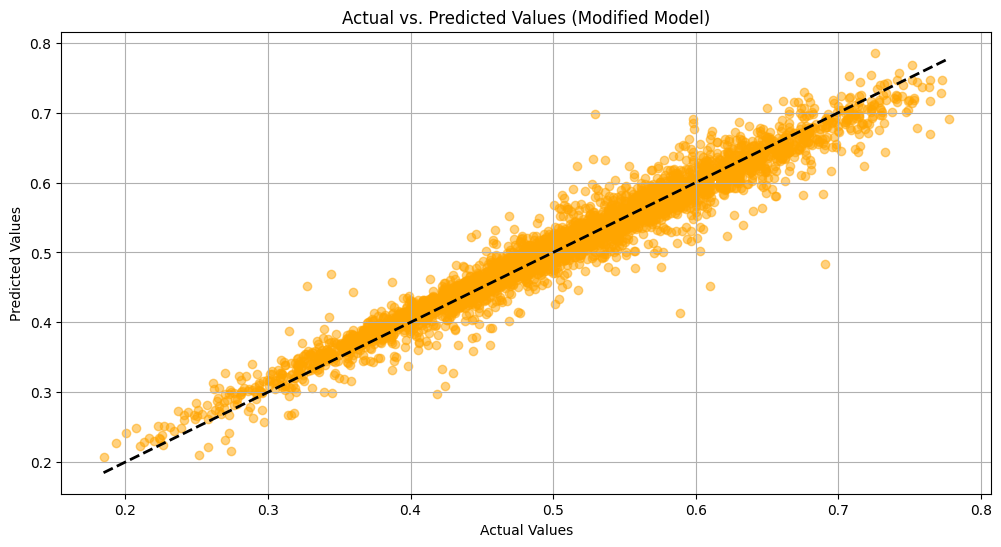

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure models and test data are available
if 'model' in locals() and 'model_modified' in locals() and 'X_test_reshaped' in locals() and 'y_test_reshaped' in locals():

    # Make predictions
    y_pred_baseline = model.predict(X_test_reshaped)
    y_pred_modified = model_modified.predict(X_test_reshaped)

    # Flatten the arrays for plotting if they are not already 1D
    y_test_flat = y_test_reshaped.flatten()
    y_pred_baseline_flat = y_pred_baseline.flatten()
    y_pred_modified_flat = y_pred_modified.flatten()


    # Plot Actual vs. Predicted for Baseline Model
    plt.figure(figsize=(12, 6))
    plt.scatter(y_test_flat, y_pred_baseline_flat, alpha=0.5)
    plt.plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], 'k--', lw=2) # Diagonal line
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Actual vs. Predicted Values (Baseline Model)")
    plt.grid(True)
    plt.show()

    # Plot Actual vs. Predicted for Modified Model
    plt.figure(figsize=(12, 6))
    plt.scatter(y_test_flat, y_pred_modified_flat, alpha=0.5, color='orange')
    plt.plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], 'k--', lw=2) # Diagonal line
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Actual vs. Predicted Values (Modified Model)")
    plt.grid(True)
    plt.show()

else:
    print("Models or test data not found. Please ensure previous steps were executed successfully.")

### Summary:

**Baseline Model**
* Arsitektur: 1 LSTM layer (10 units) + 1 Dense layer (linear)
* MAE (Mean Absolute Error): 0.01286
* MSE (Mean Squared Error): 0.00038
* R² Score: 0.9562
* Model sederhana namun memberikan performa yang sangat baik dan stabil. Memiliki error terkecil dan kemampuan prediktif paling tinggi dibanding modified model.

**Modified Model**
* Arsitektur: 2 LSTM layers (50 units each) + 2 Dropout layers + 1 Dense layer (linear)
* MAE: 0.01386
* MSE: 0.00040
* R² Score: 0.9534
* Model lebih kompleks dengan dropout dan tuning hyperparameter, namun performanya sedikit di bawah baseline. Indikasi overfitting kecil kemungkinan masih ada, meskipun sudah dilakukan regularisasi.

BASELINE MODEL IS THE WINNER!!